## 习题 1-1
载入图像 `dog.jpg`，并计算其**完整 SVD**。选择一个秩 $r<m$，验证矩阵 $U^*U$ 是一个 $r\times r$ 的单位矩阵。然后再验证 $UU^*$ 并不是单位矩阵。

计算当秩 $r$ 从 $1$ 变化到 $n$ 时，$UU^*$ 与 $n\times n$ 单位矩阵之间误差的范数，并将该误差作图。

In [1]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os

Task1: 入图像 `dog.jpg`，并计算其**完整 SVD**

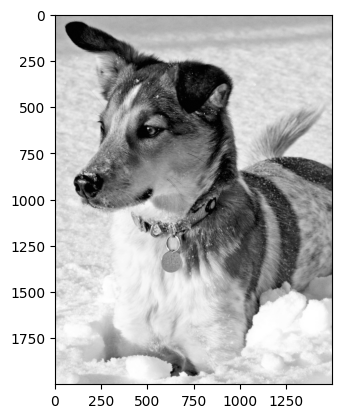

In [2]:
A = imread(os.path.join('dog.jpg'))
X = np.mean(A,-1)
img = plt.imshow(X)
img.set_cmap('gray')

In [3]:
# 计算完整的 SVD
U, Sigma, V_T = np.linalg.svd(X, full_matrices=True)

Task2: 验证矩阵 $U^*U$ 是一个 $r\times r$ 的单位矩阵

In [4]:
# 取一个r
r = 50

In [5]:
# 截U
U_r = U[:,0:r]

In [6]:
# 求共轭转置
U_r_T = np.conjugate(U_r).T

In [7]:
# 验证单位阵
result_2 = U_r_T @ U_r
result_2

array([[ 1.00000000e+00, -1.79856605e-16, -1.27954779e-16, ...,
         4.34549347e-17, -1.04804841e-17, -5.96511728e-17],
       [-1.79856605e-16,  1.00000000e+00, -5.51258682e-17, ...,
        -1.04398203e-17, -2.76728633e-17, -2.27842485e-17],
       [-1.27954779e-16, -5.51258682e-17,  1.00000000e+00, ...,
         2.73610649e-17, -9.29682278e-17,  4.55966226e-17],
       ...,
       [ 4.34549347e-17, -1.04398203e-17,  2.73610649e-17, ...,
         1.00000000e+00, -2.33856906e-16, -3.32611169e-17],
       [-1.04804841e-17, -2.76728633e-17, -9.29682278e-17, ...,
        -2.33856906e-16,  1.00000000e+00,  1.10651788e-16],
       [-5.96511728e-17, -2.27842485e-17,  4.55966226e-17, ...,
        -3.32611169e-17,  1.10651788e-16,  1.00000000e+00]],
      shape=(50, 50))

Task3: 然后再验证 $UU^*$ 并不是单位矩阵。

In [8]:
result_3 = U_r @ U_r_T
result_3

array([[0.00384071, 0.00380733, 0.00377885, ..., 0.00340112, 0.00354647,
        0.00362552],
       [0.00380733, 0.00380143, 0.00377304, ..., 0.00339432, 0.00354642,
        0.00362795],
       [0.00377885, 0.00377304, 0.00380052, ..., 0.00340164, 0.00353677,
        0.00361082],
       ...,
       [0.00340112, 0.00339432, 0.00340164, ..., 0.00641611, 0.00643405,
        0.0064413 ],
       [0.00354647, 0.00354642, 0.00353677, ..., 0.00643405, 0.00656999,
        0.00663337],
       [0.00362552, 0.00362795, 0.00361082, ..., 0.0064413 , 0.00663337,
        0.00677144]], shape=(2000, 2000))

Task4: 计算当秩 $r$ 从 $1$ 变化到 $n$ 时，$UU^*$ 与 $n\times n$ 单位矩阵之间误差的范数，并将该误差作图。

In [9]:
# r \in [1,n]
n = X.shape[0]
r_array = np.arange(1,n+1,1)

In [10]:
error_array = []
for r in r_array:
    U_r = U[:,0:r]
    U_r_T = np.conjugate(U_r).T
    Error = U_r @ U_r_T - np.eye(n)
    error = np.linalg.norm(Error,ord='fro')
    error_array.append(error)


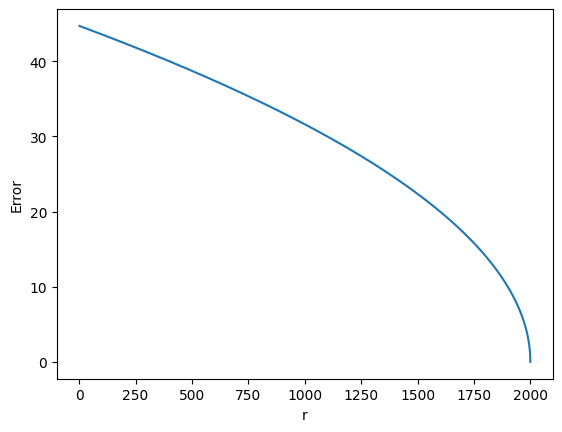

In [11]:
plot = plt.plot(r_array,error_array)
plt.xlabel('r')
plt.ylabel('Error')
plt.show()